In [1]:
#!pip install pyMultiOmics
#https://github.com/glasgowcompbio/pyMultiOmics/blob/main/notebooks/mapping_covid.ipynb

In [2]:
"""
import os, sys
import pylab as plt
import matplotlib

import numpy as np
import pandas as pd

sys.path.append('..')

from pyMultiOmics.base import SingleOmicsData, MultiOmicsData
from pyMultiOmics.constants import HOMO_SAPIENS, PROTEINS, COMPOUNDS, REACTIONS
from pyMultiOmics.mapping import Mapper
from pyMultiOmics.common import set_log_level_info, set_log_level_debug, download_file, extract_zip_file
"""

"\nimport os, sys\nimport pylab as plt\nimport matplotlib\n\nimport numpy as np\nimport pandas as pd\n\nsys.path.append('..')\n\nfrom pyMultiOmics.base import SingleOmicsData, MultiOmicsData\nfrom pyMultiOmics.constants import HOMO_SAPIENS, PROTEINS, COMPOUNDS, REACTIONS\nfrom pyMultiOmics.mapping import Mapper\nfrom pyMultiOmics.common import set_log_level_info, set_log_level_debug, download_file, extract_zip_file\n"

In [1]:
import scanpy as sc
import mudata as md
import anndata as ad
import numpy as np
import scipy.sparse as sp
import pandas as pd
#import scvi

In [2]:
# Load your original multi-modal AnnData object
adata = sc.read_h5ad("BMMC_processed.h5ad")

adata

/home/mccwen/.local/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 90261 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [3]:
# Concatenate GEX and ADT PCAs
joint_pca = np.concatenate([adata.obsm['GEX_X_pca'], adata.obsm['ADT_X_pca']], axis=1)
adata.obsm['joint_pca'] = joint_pca

In [4]:
# You can directly run UMAP on the joint PCA
sc.pp.neighbors(adata, use_rep='joint_pca', n_neighbors=15, n_pcs=50)
sc.tl.umap(adata)

2025-04-30 22:37:08.932706: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746067028.948589  651761 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746067028.953383  651761 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746067028.965680  651761 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746067028.965697  651761 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746067028.965703  651761 computation_placer.cc:177] computation placer alr

In [7]:
adata

AnnData object with n_obs × n_vars = 90261 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism', 'neighbors', 'umap'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'joint_pca', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [8]:
adata.obs['cell_type'].nunique()

45

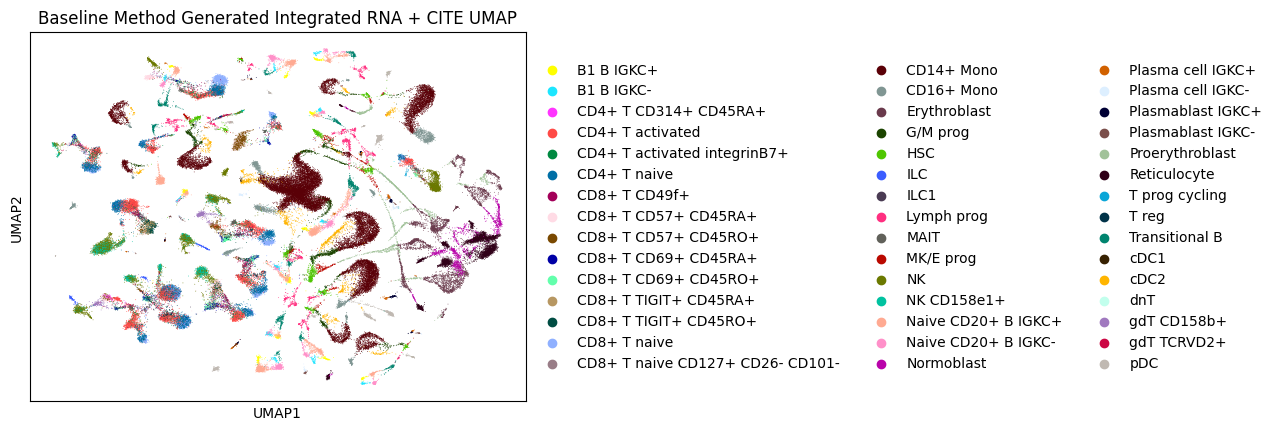

In [6]:
# Plot by cell type
#sc.pl.umap(adata, color='cell_type', title='Baseline Method Generated Integrated RNA + CITE UMAP', save= "baseline_multi_omic_UMAP.svg")
sc.pl.umap(adata, color='cell_type', title='Baseline Method Generated Integrated RNA + CITE UMAP', save= "baseline_multi_omic_UMAP.pdf")

## Calculate Adjusted Rand Index (ARI)

In [18]:
from sklearn.metrics import adjusted_rand_score

# Ground truth labels
true_labels = adata.obs['cell_type']

# Predicted clusters
predicted_clusters = adata.obs['leiden']

# Compute ARI
ari_score = adjusted_rand_score(true_labels, predicted_clusters)

print(f'Adjusted Rand Index (ARI): {ari_score:.3f}')

Adjusted Rand Index (ARI): 0.265


## Calculate Average Silhouette Width (ASW)

In [20]:
from sklearn.metrics import silhouette_score
#Features: use joint UMAP (default in Scanpy after running integration)
#X = adata.obsm['X_umap']
X = adata.obsm['joint_pca']

# Labels: use your true biological labels (e.g., 'cell_type')
labels = adata.obs['cell_type']

# Calculate Silhouette Score
asw = silhouette_score(X, labels)

print(f'Average Silhouette Width (ASW) based on cell types: {asw:.3f}')

Average Silhouette Width (ASW) based on cell types: -0.035


## Calculate Normalized Mutual Information (NMI)

In [21]:
from sklearn.metrics import normalized_mutual_info_score

# Step 1: Make sure neighbors are already built on the integrated embeddings
# (You probably already did sc.pp.neighbors(adata, use_rep='joint_pca') or similar)

# Step 2: Initialize variables to store best NMI and best resolution
best_nmi = 0
best_resolution = 0

# Step 3: Sweep through resolutions
for res in np.arange(0.1, 2.1, 0.1):
    # Perform Louvain clustering
    sc.tl.louvain(adata, resolution=res, key_added=f'louvain_{res:.1f}')
    
    # Ground truth labels
    true_labels = adata.obs['cell_type']
    
    # Predicted cluster labels
    cluster_labels = adata.obs[f'louvain_{res:.1f}']
    
    # Compute NMI
    nmi = normalized_mutual_info_score(true_labels, cluster_labels)
    
    # Check if this is the best NMI
    if nmi > best_nmi:
        best_nmi = nmi
        best_resolution = res

# Step 4: Report best result
print(f'Best NMI_cell = {best_nmi:.3f} at resolution = {best_resolution:.1f}')


Best NMI_cell = 0.550 at resolution = 2.0


## Calculate Aggregated Metrics (AvgBIO)
#### AvgBIO= (NMI + ASW + ARI)/3

In [22]:
best_nmi

np.float64(0.5501431986837254)

In [23]:
avg_bio= (ari_score + asw + best_nmi)/3
print(avg_bio)

0.2599454974183992
